# Exploratory Data Analysis

## Understanding the problem statement

The goal of this analysis is to predict whether a customer visiting an e-commerce website will complete a purchase using the available dataset. The data contains features that are potentially informative for understanding customer behavior, including a mix of numerical variables (e.g. ExitRate) and categorical variables (e.g.| GeographicRegion). Some variables, such as PageValue, appear more complex and may require additional investigation to fully understand their interpretation and relevance to purchase behavior.

In [1]:
# import relevant librraries
import pandas as pd
import numpy as np
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler # install scikit-learn library first

Libraries such as pandas and numpy are commonly used especially when handling data. sqlite3 library allows to use and access database files. 

## Connect to database

In [2]:
# connect to the database 
connection = sqlite3.connect('data/online_shopping.db')

# crate a cursor to execute SQL comments 
#cursor = connection.cursor()

# use SQL commands to view dataset
query = 'SELECT * FROM online_shopping;'
df = pd.read_sql_query(query, connection)

print(df)

            CustomerType  SpecialDayProximity  ExitRate  PageValue  \
0      Returning_Visitor                  0.0  0.200000   0.000000   
1      Returning_Visitor                  0.0  0.100000   0.000000   
2      Returning_Visitor                  NaN  0.200000   0.000000   
3      Returning_Visitor                  0.0  0.140000   0.000000   
4      Returning_Visitor                  0.0       NaN        NaN   
...                  ...                  ...       ...        ...   
12325  Returning_Visitor                  0.0  0.029031  12.241717   
12326  Returning_Visitor                  0.0  0.021333        NaN   
12327  Returning_Visitor                  0.0  0.086667   0.000000   
12328  returning_Visitor                  0.0  0.021053   0.000000   
12329        New_Visitor                  0.0  0.066667   0.000000   

       TrafficSource  GeographicRegion  BounceRate  ProductPageTime  \
0                1.0                 1    0.200000         0.000000   
1                

The summary of the data shows that there are columns with missing entries. A closer look is required to see how many many enties are missing and if it affects the overall data quality. 

In [3]:
# count number of missing values per row 
print("\nNumber of missing values per column:")
print(df.isna().sum())

# show if the whole row is affected 
missing_val = df[df.isnull().any(axis=1)]
print(missing_val)


Number of missing values per column:
CustomerType             0
SpecialDayProximity    616
ExitRate               616
PageValue              616
TrafficSource          616
GeographicRegion         0
BounceRate               0
ProductPageTime        616
PurchaseCompleted        0
dtype: int64
            CustomerType  SpecialDayProximity  ExitRate  PageValue  \
2      Returning_Visitor                  NaN  0.200000   0.000000   
4      Returning_Visitor                  0.0       NaN        NaN   
7      Returning_Visitor                  0.0  0.200000   0.000000   
16     Returning_Visitor                  0.0  0.200000   0.000000   
34     Returning_Visitor                  NaN  0.028571   0.000000   
...                  ...                  ...       ...        ...   
12297        New_Visitor                  0.0       NaN   0.000000   
12309  Returning_Visitor                  0.0       NaN   0.000000   
12310  Returning_Visitor                  0.0       NaN   0.000000   
12325 

Out of the original 12,330 rows, 2,778 rows contain at least one missing value. These missing values are present in the following columns: SpecialDayProximity, ExitRate, PageValue, TrafficSource, and ProductPageTime.

To ensure accuracy of the exploratory analysis, these rows were removed from the dataset. The resulting dataset still contains a sufficient number of observations to support meaningful analysis and further machine learning processing.

In [4]:
df_clean = df.dropna()
print(df_clean.isna().sum())

CustomerType           0
SpecialDayProximity    0
ExitRate               0
PageValue              0
TrafficSource          0
GeographicRegion       0
BounceRate             0
ProductPageTime        0
PurchaseCompleted      0
dtype: int64


## First look at the data

In [5]:
df_clean.describe(include='all')

,CustomerType,SpecialDayProximity,ExitRate,PageValue,TrafficSource,GeographicRegion,BounceRate,ProductPageTime,PurchaseCompleted
count,9552,9552.000000,9552.000000,9552.000000,9552.000000,9552.000000,9552.000000,9552.000000,9552.000000
unique,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,Returning_Visitor,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,7756,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,0.060553,0.042821,5.976380,4.047843,2.827994,0.019808,1195.276432,0.155779
std,NaN,0.197274,0.048417,18.947997,4.004436,2.766379,0.049128,1945.736439,0.362665
min,NaN,0.000000,0.000000,0.000000,1.000000,-9.000000,-0.200000,-35.000000,0.000000
25%,NaN,0.000000,0.014035,0.000000,2.000000,1.000000,0.000000,184.775000,0.000000
50%,NaN,0.000000,0.025014,0.000000,2.000000,2.000000,0.001869,607.483333,0.000000
75%,NaN,0.000000,0.050000,0.000000,4.000000,4.000000,0.015385,1464.834616,0.000000


Initial look and information provided about attributes show that there is a mix of numerical and categorical vairbles, and is seperated to get a more accurate summary.

- ProductPageTime: time spent on page in seconds - continuous
- BounceRate: percentage of single page sessions- continuous 
- ExitRate: percentage of exit from specific pages - continuous 
- PageValue: Average value of pages before completing a transaction - discrete
- SpecialDayProximity: number range from 0.0 to 1.0 to represent closeness - categorical
- GeographicRegion: assumption that regions are catogorized from "-9" to "9" - categorical
- TrafficSource: assumption that each number(in decimal) references a source - categorical 
- CustomerType: type of visitors to the website - categorical 
- PurchaseCompleted: boolean(true/false) value representing if visitor made a purchase - categorical 



Classifying data into numerical and categorical is crucial because the methods of analysing them are different. Numerical data, as the name suggest, is information that is represented by numbers, meaning that mathamatical formulas can be applied to get an easier understanding or new information. Categorical data can take any form as they have their own meaning or interpretation, therefore it is not feasible to apply mathematical formulas to them and in fact, doing any transformation carries risk of losing informtation in the data. 

For the analysis in this document, the data provided in the online_shopping database have been classified as above. Key points to note is that some of the attributes are entered as numerical data but they are categorical data based on the context. Futhermore, only the context of data is provided but not the scale or units of measurement. **Therefore, several assumptions are made:**


## Quick look at categorical data 

### PurchaseCompleted

In [29]:
number = df_clean['PurchaseCompleted'].value_counts()
print(number)

PurchaseCompleted
0    8064
1    1488
Name: count, dtype: int64


The number of purchases not completed to completed ones is almost 1:5. Such imbalance in the response can introduce bias in model training and may indicate that the data is not randomly sampled which will have to be considered when interepreting model results. 

In [6]:
# dataframe for categorical data
df_cat = df_clean[['SpecialDayProximity', 'GeographicRegion', 'TrafficSource', 'CustomerType', 'PurchaseCompleted']]
print("\nSummary of Categorical values")
print(df_cat.describe())


Summary of Categorical values
       SpecialDayProximity  GeographicRegion  TrafficSource  PurchaseCompleted
count          9552.000000       9552.000000    9552.000000        9552.000000
mean              0.060553          2.827994       4.047843           0.155779
std               0.197274          2.766379       4.004436           0.362665
min               0.000000         -9.000000       1.000000           0.000000
25%               0.000000          1.000000       2.000000           0.000000
50%               0.000000          2.000000       2.000000           0.000000
75%               0.000000          4.000000       4.000000           0.000000
max               1.000000          9.000000      20.000000           1.000000


In [7]:
print("\nUnique elements in SpecialDayProximity:")
print(df_cat['SpecialDayProximity'].unique())

print("\nUnique elements in GeographicRegion:")
print(df_cat['GeographicRegion'].unique())

print("\nUnique elements in TrafficSource:")
print(df_cat['TrafficSource'].unique())

print("\nUnique elements in CustomerType:")
print(df_cat['CustomerType'].unique())

print("\nUnique elements in PurchaseCompleted:")
print(df_cat['PurchaseCompleted'].unique())


Unique elements in SpecialDayProximity:
[0.  0.4 0.8 1.  0.2 0.6]

Unique elements in GeographicRegion:
[ 1  2  3  4 -3  9  5  6  7  8 -4 -1 -6 -8 -2 -5 -7 -9]

Unique elements in TrafficSource:
[ 1.  2.  4.  3.  5.  6.  7.  8.  9. 10. 12. 11. 13. 14. 15. 18. 19. 16.
 17. 20.]

Unique elements in CustomerType:
<StringArray>
['Returning_Visitor',                  '',               'nan',
           'Unknown',              'None',       'New_Visitor',
             'Other', 'returning_Visitor']
Length: 8, dtype: str

Unique elements in PurchaseCompleted:
[0 1]


The CustomerType variable contains missing and inconsistent entries, including "nan" and "None". To ensure data integrity and maintain quality for further analysis, it is assumed that missing values, "Unknown", "nan", and "None" all refer to the same customer type. These entries are therefore standardized and replaced with "Unknown". The category "Other" is retained, as it may represent a distinct group with potential significance that was not documented in the technical specifications.

In [8]:
# change the relevant values to "Unknown" and the lowercase returning to uppercase
df_cat['CustomerType']= df_cat['CustomerType'].replace({'': 'Unknown', 'nan':'Unknown', 'None':'Unknown', 'returning_Visitor': 'Returning_Visitor'})

print("\nUnique elements in CustomerType:")
print(df_cat['CustomerType'].unique())

# changed 0s to False and 1s to True in PurchaseCompleted
df_cat['PurchaseCompleted'] = df_cat['PurchaseCompleted'].replace({0:'False', 1: 'True'})

print("\nUnique elements in PurchaseCompleted:")
print(df_cat['PurchaseCompleted'].unique())


Unique elements in CustomerType:
<StringArray>
['Returning_Visitor', 'Unknown', 'New_Visitor', 'Other']
Length: 4, dtype: str

Unique elements in PurchaseCompleted:
['False' 'True']


### CustomerType

<function matplotlib.pyplot.show(close=None, block=None)>

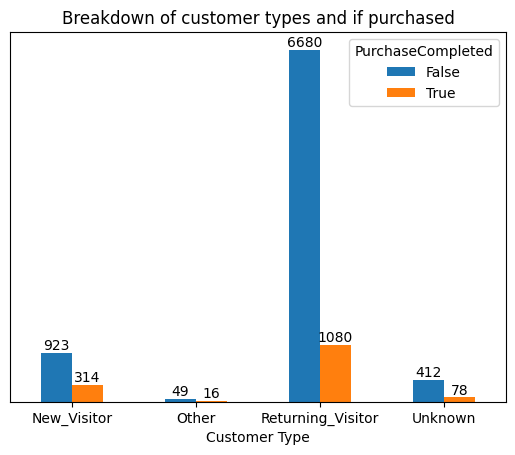

In [33]:
crosstab_customer = pd.crosstab(index=df_cat['CustomerType'], columns=df_cat['PurchaseCompleted'])
cross_cus_plot = crosstab_customer.plot(kind= 'bar')

for c in cross_cus_plot.containers:
    cross_cus_plot.bar_label(c)

cross_cus_plot.yaxis.set_visible(False)

plt.title('Breakdown of customer types and if purchased')
plt.xlabel('Customer Type')
plt.xticks(rotation =0) 
plt.show

In [34]:
# calculate ratios of customers who made a purchase 

# function to calculate ratios using numbers shown in the bar charts
def ratios(true_num, false_num):
    total = true_num + false_num
    ratio = (true_num/total)*100
    return ratio

crosstab_customer['Purchase_Ratio'] = crosstab_customer.apply(
    lambda row: ratios(row['True'], row['False']), axis=1
    )

print("Ratio of purchase by customer type:")
print(crosstab_customer['Purchase_Ratio'].round(2))

Ratio of purchase by customer type:
CustomerType
New_Visitor          25.38
Other                24.62
Returning_Visitor    13.92
Unknown              15.92
Name: Purchase_Ratio, dtype: float64


Even though there are more returning visitors, new visitors are more likely to complete a purchase 

### SpecialDayProximity

<function matplotlib.pyplot.show(close=None, block=None)>

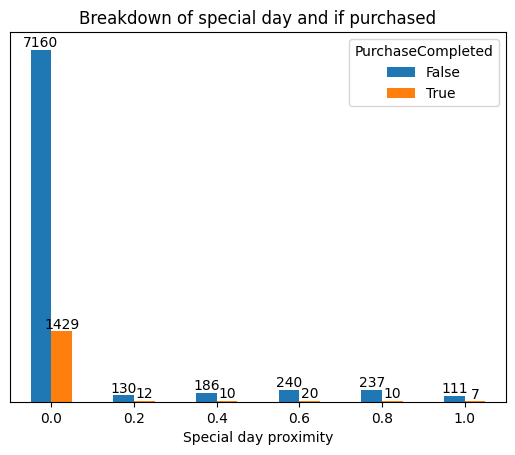

In [35]:
crosstab_day = pd.crosstab(index=df_cat['SpecialDayProximity'], columns=df_cat['PurchaseCompleted'])
cross_day_plot = crosstab_day.plot(kind= 'bar')

for d in cross_day_plot.containers:
    cross_day_plot.bar_label(d)

cross_day_plot.yaxis.set_visible(False)

plt.title('Breakdown of special day and if purchased')
plt.xlabel('Special day proximity')
plt.xticks(rotation =0) 
plt.show

In [36]:
# calculate ratios for purchases according to proximity to a special day 
crosstab_day['Purchase_Ratio'] = crosstab_day.apply(
    lambda row: ratios(row['True'], row['False']), axis=1
    )

print("Ratio of purchase by proximity to a special day:")
print(crosstab_day['Purchase_Ratio'].round(2))

Ratio of purchase by proximity to a special day:
SpecialDayProximity
0.0    16.64
0.2     8.45
0.4     5.10
0.6     7.69
0.8     4.05
1.0     5.93
Name: Purchase_Ratio, dtype: float64


### GeographicRegion 

<function matplotlib.pyplot.show(close=None, block=None)>

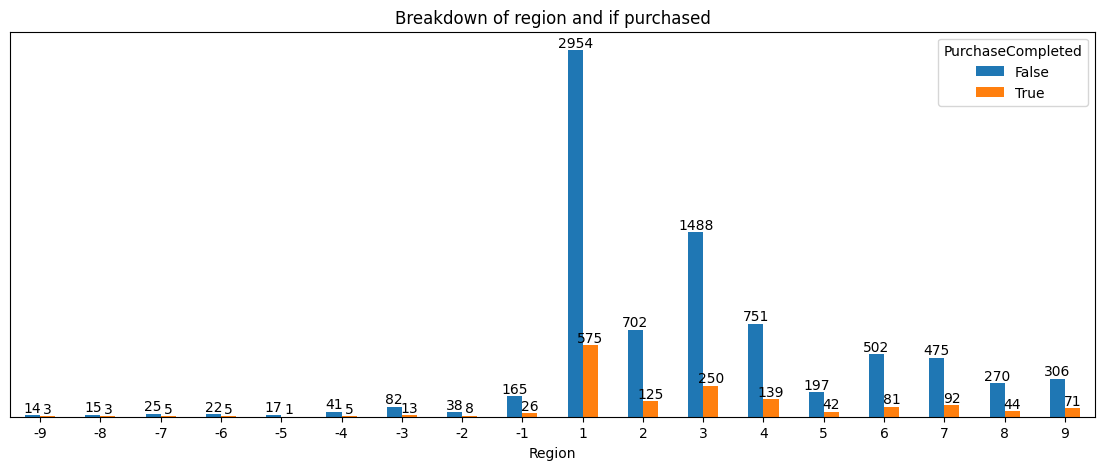

In [37]:
crosstab_geo = pd.crosstab(index=df_cat['GeographicRegion'], columns=df_cat['PurchaseCompleted'])
cross_geo_plot = crosstab_geo.plot(kind= 'bar', figsize=(14,5)) # make the chart output wider since this one has many x variables

for g in cross_geo_plot.containers:
    cross_geo_plot.bar_label(g)

cross_geo_plot.yaxis.set_visible(False)

plt.title('Breakdown of region and if purchased')
plt.xlabel('Region')
plt.xticks(rotation =0)
plt.show

In [38]:
# calculate ratios for purchases according to region 
crosstab_geo['Purchase_Ratio'] = crosstab_geo.apply(
    lambda row: ratios(row['True'], row['False']), axis=1
    )

print("Ratio of purchase by proximity to a special day:")
print(crosstab_geo['Purchase_Ratio'].round(2))

Ratio of purchase by proximity to a special day:
GeographicRegion
-9    17.65
-8    16.67
-7    16.67
-6    18.52
-5     5.56
-4    10.87
-3    13.68
-2    17.39
-1    13.61
 1    16.29
 2    15.11
 3    14.38
 4    15.62
 5    17.57
 6    13.89
 7    16.23
 8    14.01
 9    18.83
Name: Purchase_Ratio, dtype: float64


### TrafficSource

<function matplotlib.pyplot.show(close=None, block=None)>

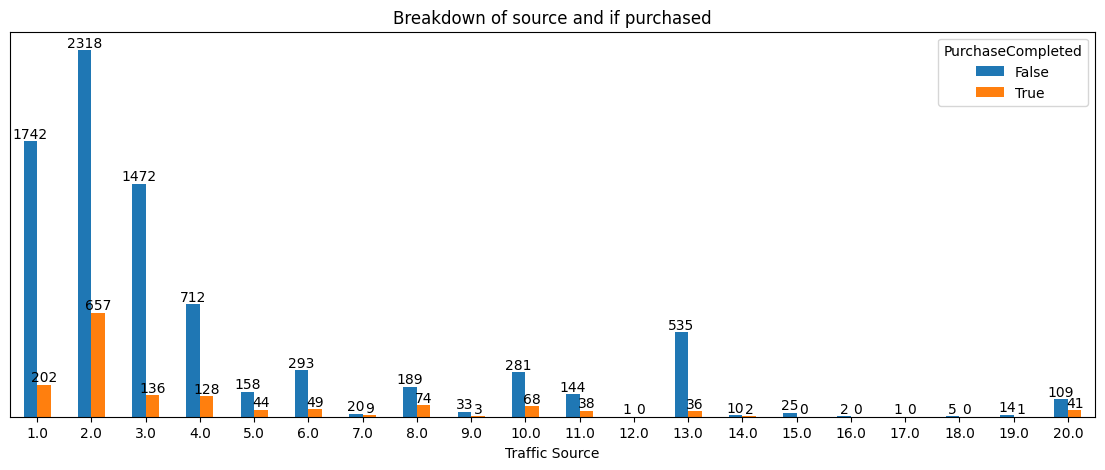

In [39]:
crosstab_source = pd.crosstab(index=df_cat['TrafficSource'], columns=df_cat['PurchaseCompleted'])
cross_source_plot = crosstab_source.plot(kind= 'bar', figsize=(14,5)) # make the chart output wider since there's many x variables

for s in cross_source_plot.containers:
    cross_source_plot.bar_label(s)

cross_source_plot.yaxis.set_visible(False)

plt.title('Breakdown of source and if purchased')
plt.xlabel('Traffic Source')
plt.xticks(rotation =0)  
plt.show

In [40]:
# calculate ratios for purchases according to source 
crosstab_source['Purchase_Ratio'] = crosstab_source.apply(
    lambda row: ratios(row['True'], row['False']), axis=1
    )

print("Ratio of purchase by proximity to a special day:")
print(crosstab_source['Purchase_Ratio'].round(2))

Ratio of purchase by proximity to a special day:
TrafficSource
1.0     10.39
2.0     22.08
3.0      8.46
4.0     15.24
5.0     21.78
6.0     14.33
7.0     31.03
8.0     28.14
9.0      8.33
10.0    19.48
11.0    20.88
12.0     0.00
13.0     6.30
14.0    16.67
15.0     0.00
16.0     0.00
17.0     0.00
18.0     0.00
19.0     6.67
20.0    27.33
Name: Purchase_Ratio, dtype: float64


## Conclusion of categorical charts

Since categorical variables cannot be directly analyzed using mathematical operations, patterns and trends are primarily observed through visualizations, such as the bar charts presented here. These charts display each categorical feature, broken down by whether a purchase was completed.

By examining the purchase ratios (the number of completed purchases divided by the total number of entries for each category), it appears that a new customer visiting on a special day from Region 9 via Traffic Source 7 has the highest likelihood of completing a purchase. However, in terms of overall volume, the majority of customers are returning visitors from Region 1 via Traffic Source 2, also visiting on a special day. This contrast highlights the difference between probability of purchase per category and overall customer distribution.

## Quick look at numerical data

In [6]:
# create a dataframe for numerical data
df_num = df_clean[['ProductPageTime', 'BounceRate', 'ExitRate', 'PageValue', 'PurchaseCompleted']]  # include PurchaseCompleted casyuse its the information we want to know 

# changed 0s to False and 1s to True in PurchaseCompleted
df_num['PurchaseCompleted'] = df_num['PurchaseCompleted'].replace({0:'False', 1: 'True'})
df_num['PurchaseCompleted'] = df_num['PurchaseCompleted'].astype('category') 


print("\nSummary of numerical data")
print(df_num.describe(include='all'))


Summary of numerical data
        ProductPageTime   BounceRate     ExitRate    PageValue  \
count       9552.000000  9552.000000  9552.000000  9552.000000   
unique              NaN          NaN          NaN          NaN   
top                 NaN          NaN          NaN          NaN   
freq                NaN          NaN          NaN          NaN   
mean        1195.276432     0.019808     0.042821     5.976380   
std         1945.736439     0.049128     0.048417    18.947997   
min          -35.000000    -0.200000     0.000000     0.000000   
25%          184.775000     0.000000     0.014035     0.000000   
50%          607.483333     0.001869     0.025014     0.000000   
75%         1464.834616     0.015385     0.050000     0.000000   
max        63973.522230     0.200000     0.200000   361.763742   

       PurchaseCompleted  
count               9552  
unique                 2  
top                False  
freq                8064  
mean                 NaN  
std               

There are negative values for ProductPageTime and BounceRate, which makes no sense. Therefore assuming that it is a data entry error, all the negative values will just be replaced with the positive values. 

In [7]:
df_num[['ProductPageTime', 'BounceRate']] = df_num[['ProductPageTime', 'BounceRate']].abs()
print(df_num.describe(include='all'))

        ProductPageTime   BounceRate     ExitRate    PageValue  \
count       9552.000000  9552.000000  9552.000000  9552.000000   
unique              NaN          NaN          NaN          NaN   
top                 NaN          NaN          NaN          NaN   
freq                NaN          NaN          NaN          NaN   
mean        1195.288367     0.021938     0.042821     5.976380   
std         1945.729107     0.048215     0.048417    18.947997   
min            0.000000     0.000000     0.000000     0.000000   
25%          184.775000     0.000000     0.014035     0.000000   
50%          607.483333     0.003030     0.025014     0.000000   
75%         1464.834616     0.016667     0.050000     0.000000   
max        63973.522230     0.200000     0.200000   361.763742   

       PurchaseCompleted  
count               9552  
unique                 2  
top                False  
freq                8064  
mean                 NaN  
std                  NaN  
min               

### ProductPageTime

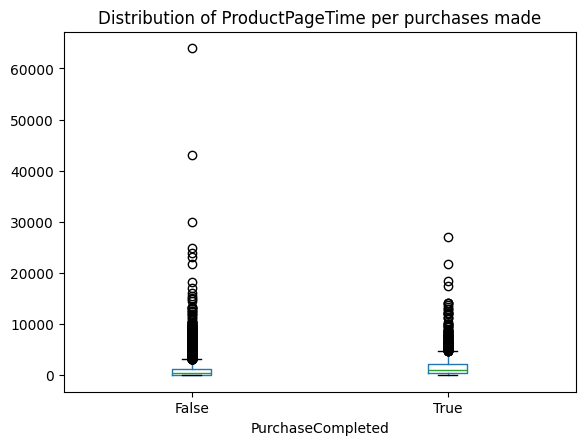

In [8]:
df_num.boxplot(column='ProductPageTime',by='PurchaseCompleted', grid=False)
plt.title("Distribution of ProductPageTime per purchases made")
plt.suptitle("")
plt.show()

### BounceRate 

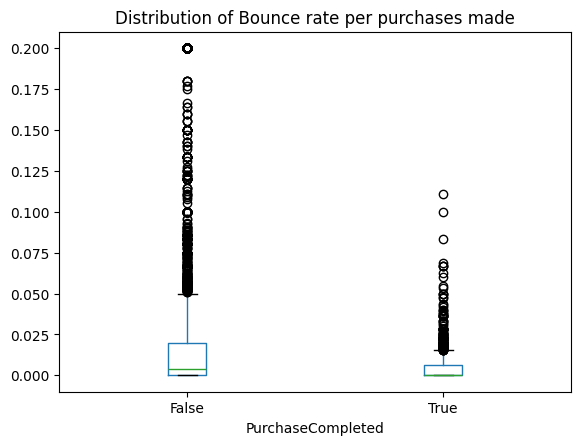

In [9]:
df_num.boxplot(column='BounceRate',by='PurchaseCompleted', grid=False)
plt.title("Distribution of Bounce rate per purchases made")
plt.suptitle("")
plt.show()

### ExitRate

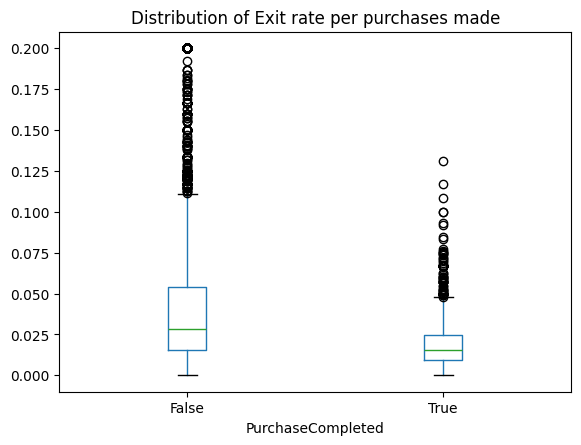

In [10]:
df_num.boxplot(column='ExitRate',by='PurchaseCompleted', grid=False)
plt.title("Distribution of Exit rate per purchases made")
plt.suptitle("")
plt.show()

### PageValue

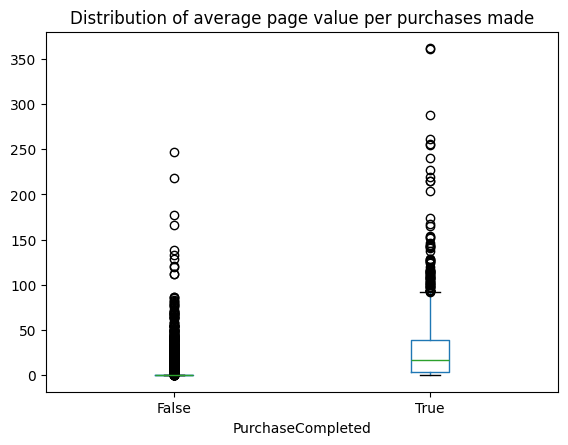

In [11]:
df_num.boxplot(column='PageValue',by='PurchaseCompleted', grid=False)
plt.title("Distribution of average page value per purchases made")
plt.suptitle("")
plt.show()

A notable characteristic of all numerical variables is that their mean values are substantially higher than their medians, indicating that the distributions are skewed and not symmetric. To better understand the spread and identify potential outliers, histogram plots can be used to visualize the distribution of each numerical feature.

### Histograms of all numerical variables

array([[<Axes: title={'center': 'ProductPageTime'}>,
        <Axes: title={'center': 'BounceRate'}>],
       [<Axes: title={'center': 'ExitRate'}>,
        <Axes: title={'center': 'PageValue'}>]], dtype=object)

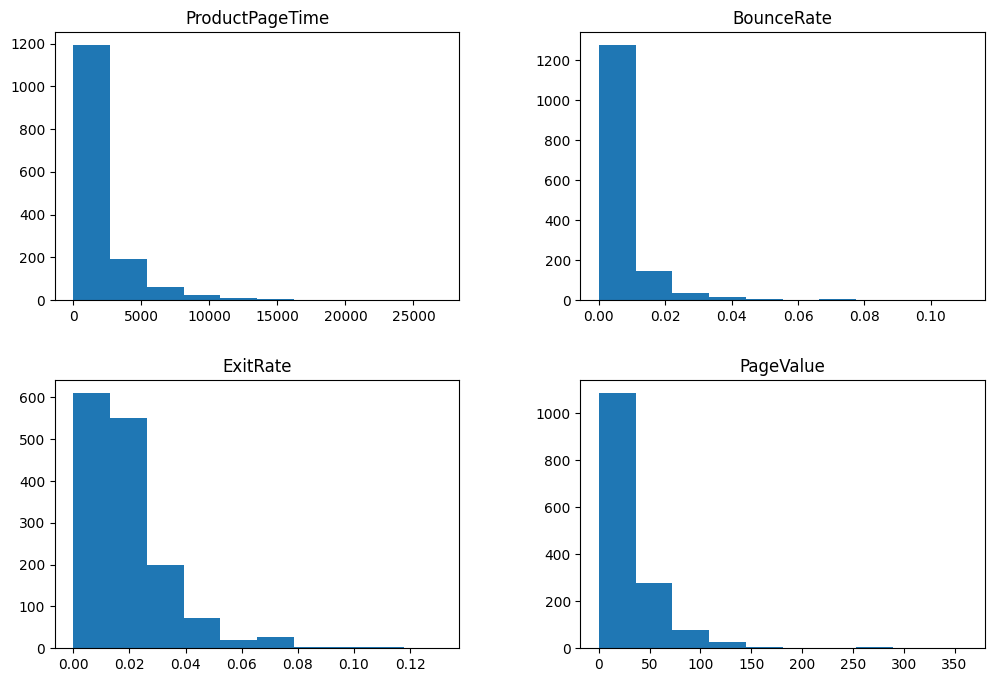

In [12]:
df_num_true = df_num[df_num['PurchaseCompleted'] == 'True']
df_num_true.hist(grid=False, figsize= (12,8))
# plt.title("Histogram of PageValue")
# plt.ylabel("count")
# plt.xlabel("PageValue")



The histograms reveal that most numerical variables are heavily left-skewed, with means much higher than medians, indicating non-symmetric distributions that may reduce their statistical informativeness. To address this, data transformations are applied to normalize these variables. BounceRate and ExitRate are excluded from normalization, as they are expressed as percentages and can be directly handled by models such as Logistic Regression. The ProductPageTime variable is strongly right-skewed, with most observations at lower values. This suggests that a transformation may be needed to better satisfy the assumption of normality for certain statistical methods.

In [13]:
# verify if there are any entries with 0 page value and purchases made
verify_true = df_num[(df_num['PageValue'] < 0.1) & (df_num['PurchaseCompleted'] == 'True')]
print(verify_true)

       ProductPageTime  BounceRate  ExitRate  PageValue PurchaseCompleted
5514        558.611111    0.009091  0.046465        0.0              True
5554       1939.571111    0.003774  0.010539        0.0              True
5561       4306.612355    0.001075  0.019376        0.0              True
5563       1199.616667    0.000000  0.006173        0.0              True
5580          0.000000    0.000000  0.066667        0.0              True
...                ...         ...       ...        ...               ...
12202       389.166667    0.000000  0.021429        0.0              True
12209        97.500000    0.000000  0.038462        0.0              True
12216      6784.671131    0.004932  0.021158        0.0              True
12230      1326.107143    0.018367  0.018160        0.0              True
12311      4627.489571    0.001361  0.020664        0.0              True

[281 rows x 5 columns]


Among the 1,488 entries where PurchaseCompleted is True, 281 have missing PageValue. According to Google Analytics [https://analytics.googleblog.com/2012/07/understanding-and-using-page-value.html], this is likely an error, as all completed purchases are expected to have a page value. These entries are therefore ignored in subsequent analysis.

Text(0.5, 0, 'ProductPageTime')

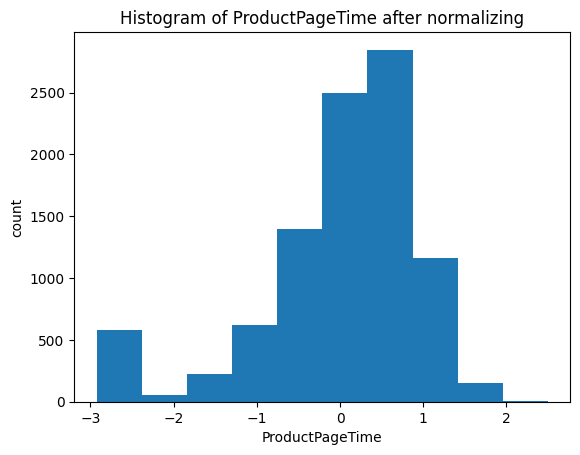

In [14]:
## normalize ProductPageTime
scale = StandardScaler()

temp = df_num.copy()

# log transform and then scale 
temp['Time_scaled'] = np.log1p(temp['ProductPageTime'])
temp['Time_scaled'] = scale.fit_transform(temp[['Time_scaled']])

temp['Time_scaled'].hist(grid=False)
plt.title("Histogram of ProductPageTime after normalizing")
plt.ylabel("count")
plt.xlabel("ProductPageTime")

Text(0.5, 0, 'PageValue')

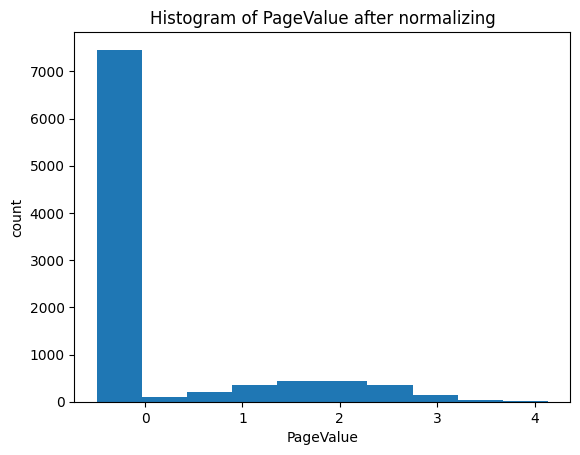

In [17]:
## normalize PageValue
# log transform and then scale 
temp['Value_scaled'] = np.log1p(temp['PageValue'])
temp['Value_scaled'] = scale.fit_transform(temp[['Value_scaled']])

temp['Value_scaled'].hist(grid=False)
plt.title("Histogram of PageValue after normalizing")
plt.ylabel("count")
plt.xlabel("PageValue")

Text(0.5, 0, 'PageValue')

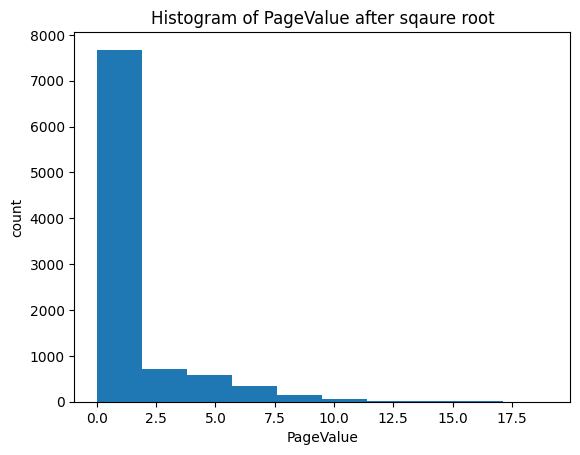

In [18]:
## try square-root
temp['sqrt'] = np.sqrt(temp['PageValue'])

temp['sqrt'].hist(grid=False)
plt.title("Histogram of PageValue after sqaure root")
plt.ylabel("count")
plt.xlabel("PageValue")

Even after applying a log transformation and sqaure root transformation, the data is still very right-skewed. The number of 0 values is overwhelming that it will alway heavily skew the data. Furthermore, given the discrepencies of having 0 page value but a purhcase made, it is deemed that this variable should not be included in any further analysis. 

### Correlations between all numerical variables

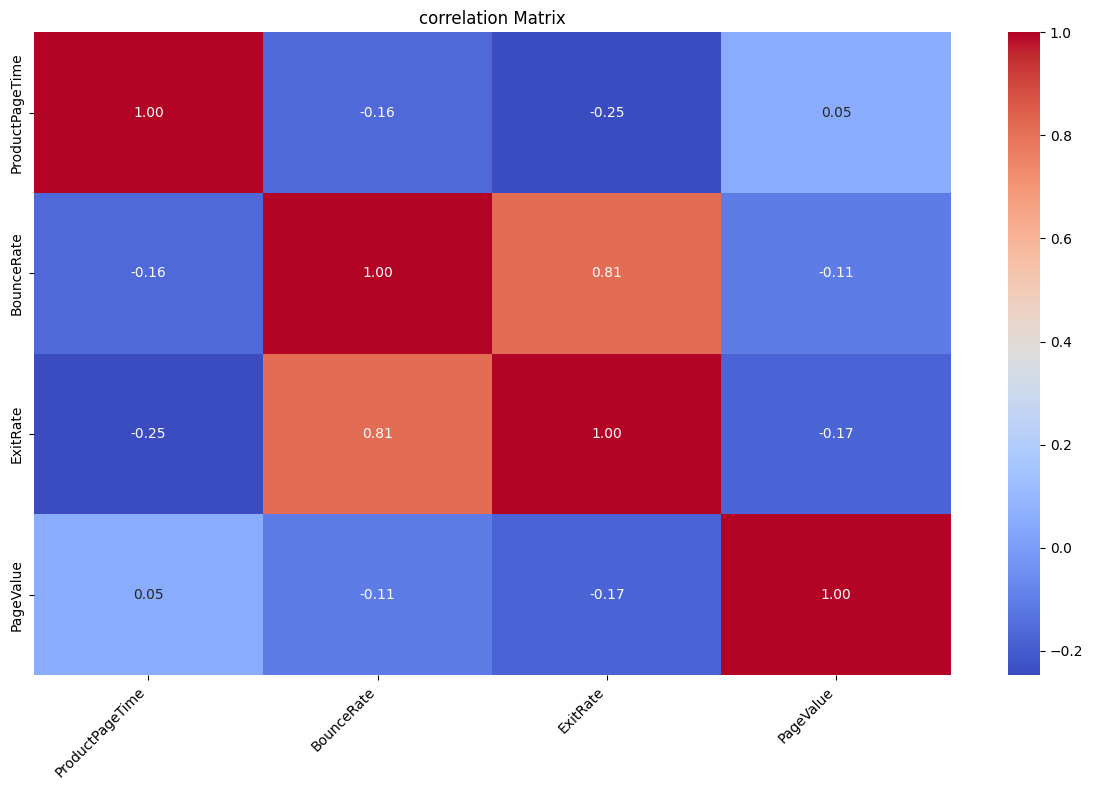

In [45]:
temp2 = df_num.copy()
temp2 = temp2.drop(columns="PurchaseCompleted")

#mask = np.triu(np.ones_like(corr, dtype=bool))

corr = temp2.corr()
plt.figure(figsize=(12,8))
sns.heatmap(corr, annot= True, fmt= ".2f", cmap="coolwarm")
plt.xticks(rotation=45, ha='right')
plt.title("correlation Matrix")
plt.tight_layout()
plt.show()



Bounce Rate and Exit Rate are highly correlated, indicating that changes in one variable are strongly associated with changes in the other. For machine learning, including both highly correlated features can lead to multicollinearity, which may reduce the accuracy and interpretability of statistical models. Therefore, one of these variables should be removed or an appropriate combination should be created to ensure more reliable model predictions.

## Logistic Regression - for part 2 

The charts above helped to identify data quality issues that required correction and provided a clearer view of the relationships between the independent variables and the target variable. However, the numerical visualizations do not reveal any discernible patterns that can directly indicate whether a visitor will complete a purchase. To gain deeper insights, the next step is to apply statistical analysis, which provides a stronger, more formal approach and lays the foundation for subsequent modeling. A key assumption when performing statistical analysis is that there is a linear relationship between the independent variables and the target variable. Since the target variable is boolean, this relationship can be modeled using Logistic Regression, which assumes a linear relationship between the independent variables and a boolean response.